# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">A predictive system to detect presence and severity of cardiovascular disease (CVD) using Binary and Multi-classification in Machine Learning Fusion approach </p>


***This is the last Code for Multi-classification fusion model-4 (SVM+LR) using weighted score fusion***

***Group-1: Akash, Masud, Soumitra,Noyon***

In [960]:
# Import core numerical library
import numpy
# Import numpy with alias for convenience
import numpy as np
# Import pandas for data manipulation
import pandas as pd
# Import pyplot for plotting
import matplotlib.pyplot as plt
# Import text classification report helper
from sklearn.metrics import classification_report
# Import metrics module as alias
import sklearn.metrics as metrics
# Import accuracy, confusion matrix and classification report together
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# Import Keras Sequential model class
from keras.models import Sequential
# Import Dense and BatchNormalization layer classes
from keras.layers import Dense ,BatchNormalization
# Import helper to split dataset into train/test
from sklearn.model_selection import train_test_split
# Import scalers for normalizing features
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [961]:
# Load the multiclass dataset from CSV into a DataFrame
data = pd.read_csv('multiclassification.csv')
# Display first 10 rows to inspect the data
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class att
0,63,1,1,145,233,0,1,150,1,2.3,0,0,0,0
1,67,1,2,160,286,1,1,108,0,1.5,1,3,1,2
2,67,1,2,120,229,1,1,129,0,2.6,1,2,2,1
3,37,1,3,130,250,1,2,187,1,3.5,0,0,1,0
4,41,0,0,130,204,1,1,172,1,1.4,2,0,1,0
5,56,1,0,120,236,1,2,178,1,0.8,2,0,1,0
6,62,0,2,140,268,1,1,160,1,3.6,0,2,1,3
7,57,0,2,120,354,1,2,163,0,0.6,2,0,1,0
8,63,1,2,130,254,1,1,147,1,1.4,1,1,2,2
9,53,1,2,140,203,0,1,155,0,3.1,0,0,2,1


In [962]:
# Select feature columns (first 13 columns) as numpy array
x = data.iloc[:,0:13].values
# Select target column (14th column) as numpy array
y = data.iloc[:,13].values

In [963]:
# Split data into training and test sets with 80:20 ratio (first attempt)
# Note: this is immediately overwritten by the 70:30 split below
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

# Split data with 70:30 ratio (this replaces the previous split)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)

# Show training set shape
X_train.shape


(212, 13)

Class=1, n=36 (16.981%)
Class=3, n=22 (10.377%)
Class=4, n=11 (5.189%)
Class=0, n=117 (55.189%)
Class=2, n=26 (12.264%)


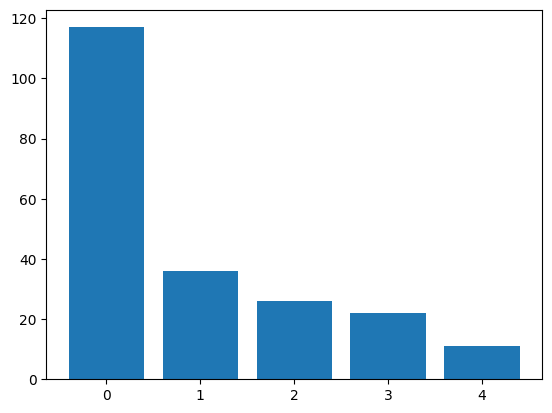

In [964]:
# Import helpers for data inspection and plotting
from pandas import read_csv
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder

# Summarize class distribution in the training set
counter = Counter(y_train)
for k,v in counter.items():
	# Calculate percentage of each class
	per = v / len(y_train) * 100
	# Print class, count and percentage
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# Plot the class distribution as a bar chart
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

The number of classes before fit Counter({np.int64(0): 117, np.int64(1): 36, np.int64(2): 26, np.int64(3): 22, np.int64(4): 11})
The number of classes after fit Counter({np.int64(1): 117, np.int64(3): 117, np.int64(4): 117, np.int64(0): 117, np.int64(2): 117})
Class=1, n=117 (20.000%)
Class=3, n=117 (20.000%)
Class=4, n=117 (20.000%)
Class=0, n=117 (20.000%)
Class=2, n=117 (20.000%)


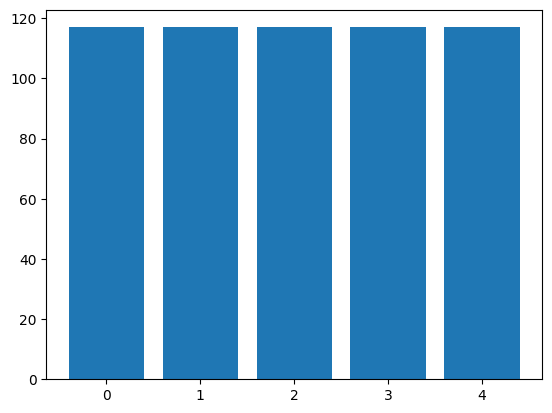

In [965]:
"""##### Over Sampling"""

# Import RandomOverSampler to balance class distribution by oversampling
from imblearn.over_sampling import RandomOverSampler

# Instantiate the oversampler
os=RandomOverSampler()
# Fit on training data and resample to obtain balanced classes
X_train_ns,y_train_ns=os.fit_resample(X_train,y_train)
# Print class counts before resampling
print("The number of classes before fit {}".format(Counter(y_train)))
# Print class counts after resampling
print("The number of classes after fit {}".format(Counter(y_train_ns)))

# Summarize new distribution
counter = Counter(y_train_ns)
for k,v in counter.items():
	# Percentage of each class after oversampling
	per = v / len(y_train_ns) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# Plot class distribution after oversampling
pyplot.bar(counter.keys(), counter.values())
pyplot.show()


In [966]:
# Replace training data with the resampled balanced data
X_train=X_train_ns
y_train=y_train_ns

# Display new training shape
X_train.shape

# Create a StandardScaler instance for algorithms that require standardization
sc = StandardScaler()

# Create a MinMaxScaler instance for algorithms that require 0-1 scaling
scaler = MinMaxScaler(feature_range=(0,1))


In [967]:
# Code to train and evaluate SVM model

# Import SVC class for Support Vector Classification
from sklearn.svm import SVC
# Instantiate SVM with probability estimates and C regularization
model1 = SVC(probability=True,C=.01)
     
# Fit StandardScaler on training data and transform
X_train_scaled = sc.fit_transform(X_train)
# Select the first 13 features for SVM (matching earlier slicing)
X_train_svc=X_train_scaled[:,0:13]
# Transform test data using the same scaler
X_test_scaled = sc.transform(X_test)
# Select features for SVM on test set
X_test_svc=X_test_scaled[:,0:13]

# Train SVM on scaled training features
model1.fit(X_train_svc,y_train)
# Predict discrete labels on test set
rounded_predictions1 = model1.predict(X_test_svc)
# Predict class probabilities on test set
predictions1 =model1.predict_proba(X_test_svc)
# Assign predicted labels to y_pred1 for later use
y_pred1 = rounded_predictions1


Accuracy of SVM =  0.6373626373626373
[[43  2  2  1  0]
 [ 9  6  1  1  1]
 [ 1  1  3  3  2]
 [ 1  2  1  5  4]
 [ 0  0  0  1  1]]
              precision    recall  f1-score   support

           0       0.80      0.90      0.84        48
           1       0.55      0.33      0.41        18
           2       0.43      0.30      0.35        10
           3       0.45      0.38      0.42        13
           4       0.12      0.50      0.20         2

    accuracy                           0.64        91
   macro avg       0.47      0.48      0.45        91
weighted avg       0.64      0.64      0.63        91



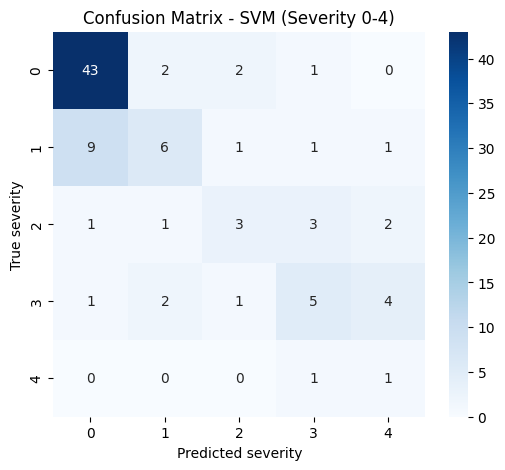

In [980]:
# Evaluate SVM predictions using sklearn metrics
import sklearn.metrics as metrics
# Compute accuracy score for SVM
scores=metrics.accuracy_score(y_test,y_pred1)
print("Accuracy of SVM = ",scores)

# Print confusion matrix for SVM predictions
cm_svm = metrics.confusion_matrix(y_test,y_pred1)
print(cm_svm)
# Print full classification report (precision/recall/f1)
print(metrics.classification_report(y_test,y_pred1))

# Plot confusion matrix heatmap for SVM
import seaborn as sns
import matplotlib.pyplot as plt
labels = [0, 1, 2, 3, 4]
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - SVM (Severity 0-4)')
plt.show()


In [969]:
# Code to train Logistic Regression (LR) model
from sklearn.metrics import roc_auc_score  
# Import LR classifier
from sklearn.linear_model import LogisticRegression 
# Import precision/recall/fscore helper
from sklearn.metrics import precision_recall_fscore_support 

# Standardize training features (fit on train)
X_train_scaled = sc.fit_transform(X_train)
# Transform test features with same scaler
X_test_scaled = sc.transform(X_test)

# Instantiate Logistic Regression with regularization parameter C
model2 =LogisticRegression(C=.1)
           

# Train Logistic Regression on scaled training data
model2.fit(X_train_scaled,y_train)

# Predict discrete labels with LR
rounded_predictions2 = model2.predict(X_test_scaled)
# Predict class probabilities with LR
predictions2 = model2.predict_proba(X_test_scaled)
# Assign predicted labels to y_pred2 for later use
y_pred2 = rounded_predictions2

Accuracy of LR =  0.5384615384615384
[[37  7  4  0  0]
 [ 8  5  2  2  1]
 [ 1  1  3  4  1]
 [ 1  2  1  4  5]
 [ 0  0  1  1  0]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        48
           1       0.33      0.28      0.30        18
           2       0.27      0.30      0.29        10
           3       0.36      0.31      0.33        13
           4       0.00      0.00      0.00         2

    accuracy                           0.54        91
   macro avg       0.35      0.33      0.34        91
weighted avg       0.56      0.54      0.55        91



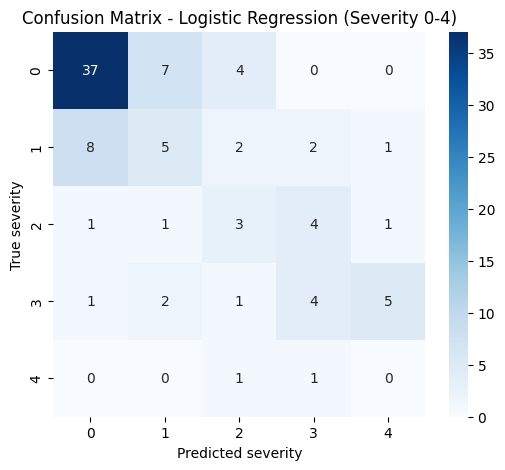

In [981]:
# Evaluate Logistic Regression predictions
import sklearn.metrics as metrics
# Compute accuracy for LR
scores2=metrics.accuracy_score(y_test,y_pred2)
print("Accuracy of LR = ",scores2)

# Confusion matrix for LR
cm_lr = metrics.confusion_matrix(y_test,y_pred2)
print(cm_lr)
# Print classification report for LR
print(metrics.classification_report(y_test,y_pred2))

# Plot confusion matrix heatmap for Logistic Regression
import seaborn as sns
import matplotlib.pyplot as plt
labels = [0, 1, 2, 3, 4]
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - Logistic Regression (Severity 0-4)')
plt.show()

In [971]:
# Search for best weight p (for predictions1) by grid stepping
p=1
# q would be 1-p
for i in range (19):
    # Decrease p by 0.05 each iteration
    p=p-.05
    # q is complementary weight
    q=1-p
    
    # Compute weighted sum of predicted probabilities from both models
    mixed=predictions1*p+predictions2*q
   

    # Prepare a list to hold final predicted class labels after fusion
    out = []
    for i in range(len(y_test)):
        # initialize placeholder for each test sample
        out.append(i)

    k=-1
    for i in range(len(y_test)):  
        k=k+1
        # Find max probability for the current sample
        for j in range(5):
            max=numpy.max(mixed[i])
        
        # Select the class index with the max probability
        for j in range(5):
            if (mixed[i][j]== max):
                out[k]=j
          

    # Convert list to numpy array of final predicted labels
    import numpy as np
    out = np.asarray(out)   
    # Compute accuracy of fused predictions
    score3=metrics.accuracy_score(out,y_test)   
    # Print accuracy and current weights
    print("  mixed  p  q","%.4f" %score3, "%.2f" %p,"%.2f" %q)

  mixed  p  q 0.5714 0.95 0.05
  mixed  p  q 0.5385 0.90 0.10
  mixed  p  q 0.5495 0.85 0.15
  mixed  p  q 0.5495 0.80 0.20
  mixed  p  q 0.5495 0.75 0.25
  mixed  p  q 0.5495 0.70 0.30
  mixed  p  q 0.5495 0.65 0.35
  mixed  p  q 0.5385 0.60 0.40
  mixed  p  q 0.5385 0.55 0.45
  mixed  p  q 0.5385 0.50 0.50
  mixed  p  q 0.5385 0.45 0.55
  mixed  p  q 0.5385 0.40 0.60
  mixed  p  q 0.5385 0.35 0.65
  mixed  p  q 0.5385 0.30 0.70
  mixed  p  q 0.5385 0.25 0.75
  mixed  p  q 0.5385 0.20 0.80
  mixed  p  q 0.5385 0.15 0.85
  mixed  p  q 0.5385 0.10 0.90
  mixed  p  q 0.5385 0.05 0.95


In [ ]:
# After tuning, set p to chosen best weight (example p=0.55)
p=.55
# q is complement of p
q=1-p
# Compute weighted probabilities using chosen weights
mixed=predictions1*p+predictions2*q

# Convert weighted probabilities into discrete predicted class labels
out = []
for i in range(len(y_test)):
    out.append(i)

k=-1
# For each test sample, choose class with maximum fused score
for i in range(len(y_test)):  
    k=k+1
    for j in range(5):
        max=numpy.max(mixed[i])
    for j in range(5):
        if (mixed[i][j]== max):
            out[k]=j
            




Accuracy of Fused Model =  0.5384615384615384


In [ ]:
# Convert output list to numpy array
import numpy as np
out = np.asarray(out)
# Compute accuracy for the selected fusion weights
score3=metrics.accuracy_score(out,y_test)   
print("Accuracy of Fused Model = ",score3)
# Compute and print confusion matrix and classification report for fused predictions
cm_fused = metrics.confusion_matrix(y_test,out)
print(cm_fused)
print(metrics.classification_report(y_test,out))

# Plot confusion matrix heatmap for Fused (SVM+LR) model
import seaborn as sns
import matplotlib.pyplot as plt
labels = [0, 1, 2, 3, 4]
plt.figure(figsize=(7,6))
sns.heatmap(cm_fused, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - Fused (SVM+LR)')
plt.show()
        
# Compute various multiclass ROC AUC scores using fused probabilities
macro_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="macro")
weighted_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="weighted")
macro_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="weighted")
# Print all ROC AUC scores (ovo and ovr, macro and weighted)
print("macro_ovo,weight_ovo,macro_ovr,weight_ovr",
        macro_roc_auc_ovo, weighted_roc_auc_ovo,macro_roc_auc_ovr ,weighted_roc_auc_ovr)

Accuracy of Fused Model =  0.5384615384615384
[[37  7  4  0  0]
 [ 8  5  2  2  1]
 [ 1  1  3  4  1]
 [ 1  2  1  4  5]
 [ 0  0  1  1  0]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        48
           1       0.33      0.28      0.30        18
           2       0.27      0.30      0.29        10
           3       0.36      0.31      0.33        13
           4       0.00      0.00      0.00         2

    accuracy                           0.54        91
   macro avg       0.35      0.33      0.34        91
weighted avg       0.56      0.54      0.55        91

macro_ovo,weight_ovo,macro_ovr,weight_ovr 0.6646118233618233 0.7520059934723398 0.7395716601339333 0.7965386801192769


In [974]:
# ROC curve computation for SVM predictions

# Binarize the multi-class labels for ROC calculations
from sklearn.preprocessing import label_binarize
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Binarize SVM predicted labels (or probabilities as needed)
y_score1 = label_binarize(y_pred1, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from numpy import interp
from itertools import cycle
n_classes=5
lw=3
# Prepare dicts to hold false positive rates, true positive rates and AUCs
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # Compute ROC curve and AUC for each class
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and area across classes
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [975]:
# Aggregate all false positive rates from each class
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate the individual ROC curves at the aggregated points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])


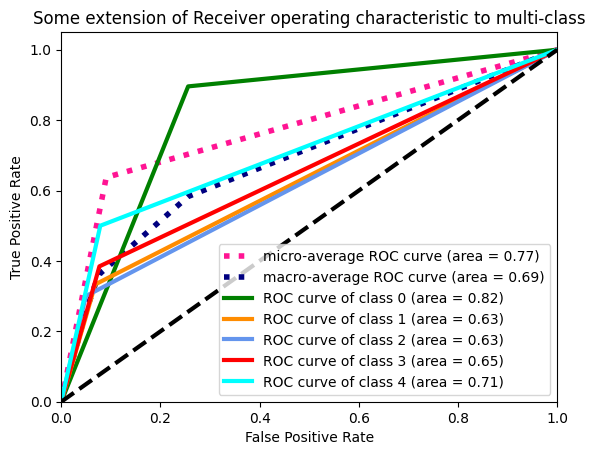

In [976]:
# Average the interpolated TPRs and compute macro AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot micro and macro average ROC curves alongside per-class curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    # Plot ROC curve for each class
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

# Diagonal line for random classifier reference
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()


In [977]:
# ROC curve computation for Logistic Regression (LR)

from sklearn.preprocessing import label_binarize
# Binarize true labels for ROC
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Binarize LR predicted labels/probabilities
y_score1 = label_binarize(y_pred2, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from numpy import interp
from itertools import cycle
n_classes=5
lw=3
# Prepare containers for ROC calculations
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # Compute ROC curve and AUC for each class
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [978]:
# Aggregate and interpolate LR ROC curves similar to SVM above
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate and accumulate TPRs
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

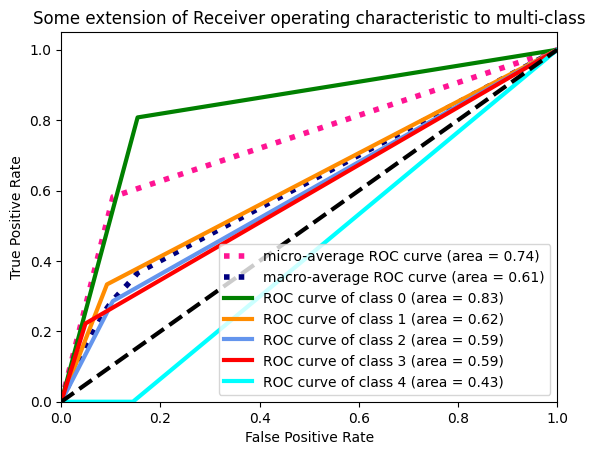

In [ ]:
# Average interpolated TPRs and plot LR ROC curves similarly
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

In [957]:
# ROC computation for the fused (SVM+LR) predictions

from sklearn.preprocessing import label_binarize
# Binarize true labels
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Binarize fused output labels/probabilities
y_score1 = label_binarize(out, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from numpy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


In [958]:
# Aggregate false positive rates for fused predictions
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate per-class ROC curves at aggregated FPR values
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Average interpolated TPR to compute macro-ROC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

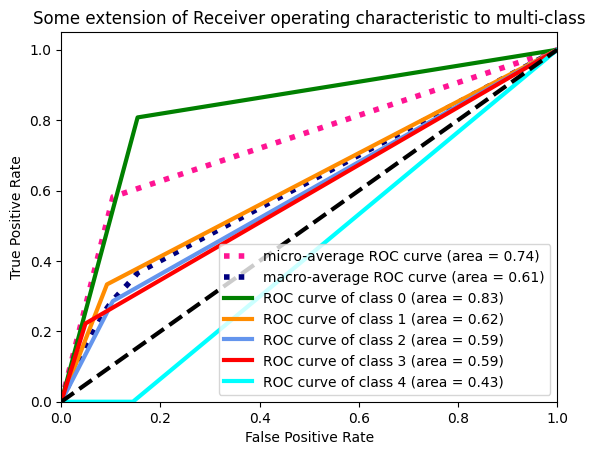

In [959]:
# Plot micro, macro and per-class ROC curves for fused model
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()